# Notebook 05 — Cluster Interpretation

**Project:** Diabetes Risk Segmentation & Decision Support System  
**Framework:** CRISP-DM — Evaluation Phase  
**User Story:** As a data analyst, I want to interpret clusters so that I can describe each patient group.

**Acceptance Criteria:**
- Each cluster has a clear, human-readable description
- Key features per cluster are identified
- Visualisations support interpretations

**Tasks:**
1. Load clustered data
2. Calculate cluster averages
3. Visualise clusters
4. Write interpretations

## 1  |  Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# ── Colour palette (one colour per cluster) ───────────────────────────────────
CLUSTER_COLOURS = {
    0: '#2196F3',   # Blue  – Cluster 0
    1: '#4CAF50',   # Green – Cluster 1
    2: '#FF5722',   # Red   – Cluster 2
}

# Provisional labels – updated after interpretation
CLUSTER_LABELS = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
}

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = '../data/processed'
MODELS_DIR = '../models'
REPORTS_DIR = '../reports/figures'
os.makedirs(REPORTS_DIR, exist_ok=True)
X = np.load(os.path.join(DATA_DIR, "X_train.npy"))

# Load clustered dataframe for labels/plotting
df = pd.read_csv(os.path.join(DATA_DIR, "clustered_data.csv"))

# Load trained KMeans model
kmeans = joblib.load(os.path.join(MODELS_DIR, "kmeans_model.joblib"))

print("Processed data shape:", X.shape)
print("Cluster centers shape:", kmeans.cluster_centers_.shape)
print("Environment ready ✓")
print('Environment ready ✓')

Processed data shape: (37417, 58)
Cluster centers shape: (3, 58)
Environment ready ✓
Environment ready ✓


## 2  |  Load Data & Artefacts

In [2]:
# ── Clustered dataset ─────────────────────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'clustered_data.csv'))

# Standardise the cluster column name (handle both 'cluster' and 'Cluster')
df.columns = [c.lower().strip() for c in df.columns]
if 'cluster' not in df.columns:
    raise ValueError("No 'cluster' column found. Check clustered_data.csv.")

# Ensure cluster column is integer type
df['cluster'] = df['cluster'].astype(int)

# ── Feature names ─────────────────────────────────────────────────────────────
feature_names_path = os.path.join(DATA_DIR, 'feature_names.csv')
if os.path.exists(feature_names_path):
    feature_names = pd.read_csv(feature_names_path, header=None)[0].tolist()
else:
    # Fall back to all numeric columns minus the cluster label
    feature_names = [c for c in df.select_dtypes(include='number').columns
                     if c != 'cluster']

# ── KMeans model ─────────────────────────────────────────────────────────────
kmeans = joblib.load(os.path.join(MODELS_DIR, 'kmeans_model.joblib'))

print(f'Dataset shape  : {df.shape}')
print(f'Clusters found : {sorted(df["cluster"].unique())}')
print(f'Feature count  : {len(feature_names)}')
df.head(3)

Dataset shape  : (97297, 35)
Clusters found : [np.int64(0), np.int64(1), np.int64(2)]
Feature count  : 59


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,age_group,bmi_category,bp_category,cluster
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,236,6.36,8.18,29.6,Type 2,1,Senior,Obese,Prehypertension,2
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,150,2.00,5.63,23.0,No Diabetes,0,Senior,Normal,Prehypertension,1
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,195,5.07,7.51,44.7,Type 2,1,Senior,Normal,Normal,2


## 3  |  Cluster Size Distribution

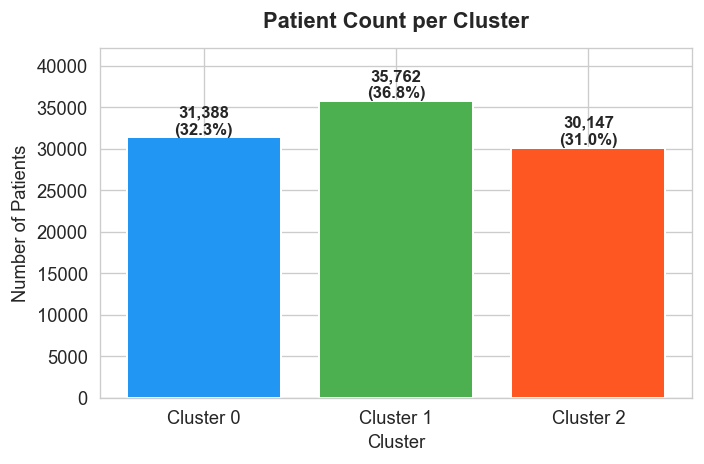

         Count
cluster       
0        31388
1        35762
2        30147


In [3]:
cluster_counts = df['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [CLUSTER_LABELS[k] for k in cluster_counts.index],
    cluster_counts.values,
    color=[CLUSTER_COLOURS[k] for k in cluster_counts.index],
    edgecolor='white', linewidth=1.2
)

for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Patient Count per Cluster', fontweight='bold', pad=12)
ax.set_ylabel('Number of Patients')
ax.set_xlabel('Cluster')
ax.set_ylim(0, cluster_counts.max() * 1.18)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'cluster_size_distribution.png'), bbox_inches='tight')
plt.show()

print(cluster_counts.rename('Count').to_frame())

## 4  |  Calculate Cluster Averages

In [4]:
# Numeric features only (exclude cluster label itself)
numeric_features = [c for c in df.select_dtypes(include='number').columns
                    if c != 'cluster']

# Per-cluster means
cluster_means = df.groupby('cluster')[numeric_features].mean().round(3)
cluster_means.index = [CLUSTER_LABELS[i] for i in cluster_means.index]

# Global mean for comparison
global_mean = df[numeric_features].mean().round(3)

# Relative deviation from global mean (as %)
cluster_deviation = ((cluster_means.subtract(global_mean) / global_mean.replace(0, np.nan)) * 100).round(1)

print('=== Cluster Feature Means ===')
display(cluster_means)

print('\n=== Deviation from Global Mean (%) ===')
display(cluster_deviation)

=== Cluster Feature Means ===


,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
Cluster 0,51.355,2.012,124.724,5.779,6.995,5.877,0.074,0.253,0.080,27.676,...,197.456,52.131,115.919,134.646,105.966,145.918,10.537,6.138,29.338,0.433
Cluster 1,42.032,1.985,136.894,6.383,6.999,5.955,0.100,0.209,0.059,22.956,...,169.942,57.116,84.766,103.897,105.454,151.682,7.152,6.265,23.446,0.472
Cluster 2,58.662,2.020,91.629,5.761,6.999,6.172,0.513,0.298,0.102,26.624,...,193.070,52.390,111.180,128.586,123.213,184.575,9.797,7.221,39.180,0.926



=== Deviation from Global Mean (%) ===


,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
Cluster 0,2.3,0.3,4.9,-3.6,-0.0,-2.0,-66.4,0.8,1.3,8.0,...,6.2,-3.5,12.5,10.9,-4.6,-8.8,16.3,-5.9,-2.9,-27.8
Cluster 1,-16.3,-1.0,15.1,6.5,0.0,-0.7,-54.5,-16.7,-25.3,-10.4,...,-8.6,5.7,-17.7,-14.5,-5.1,-5.2,-21.1,-3.9,-22.4,-21.3
Cluster 2,16.9,0.7,-23.0,-3.9,0.0,2.9,133.2,18.7,29.1,3.9,...,3.8,-3.1,7.9,5.9,10.9,15.3,8.1,10.8,29.6,54.3


## 5  |  Identify Key Distinguishing Features

In [5]:
# Features with the highest variance across cluster means are most discriminating
between_cluster_variance = cluster_means.var(axis=0).sort_values(ascending=False)

# Also compute standardised effect size (ratio of between-cluster std to global std)
global_std = df[numeric_features].std()
effect_size = (cluster_means.std(axis=0) / global_std.replace(0, np.nan)).sort_values(ascending=False)

TOP_N = 10
top_discriminating_features = effect_size.head(TOP_N).index.tolist()

print(f'Top {TOP_N} most discriminating features (by effect size):')
for rank, (feat, val) in enumerate(effect_size.head(TOP_N).items(), 1):
    print(f'  {rank:>2}. {feat:<40} effect size = {val:.3f}')

Top 10 most discriminating features (by effect size):
   1. diabetes_risk_score                      effect size = 0.877
   2. glucose_fasting                          effect size = 0.744
   3. hba1c                                    effect size = 0.728
   4. bmi                                      effect size = 0.691
   5. glucose_postprandial                     effect size = 0.674
   6. waist_to_hip_ratio                       effect size = 0.607
   7. family_history_diabetes                  effect size = 0.595
   8. diagnosed_diabetes                       effect size = 0.559
   9. age                                      effect size = 0.538
  10. ldl_cholesterol                          effect size = 0.503


## 6  |  Visualisations
### 6.1  Radar / Spider Chart — Cluster Profiles

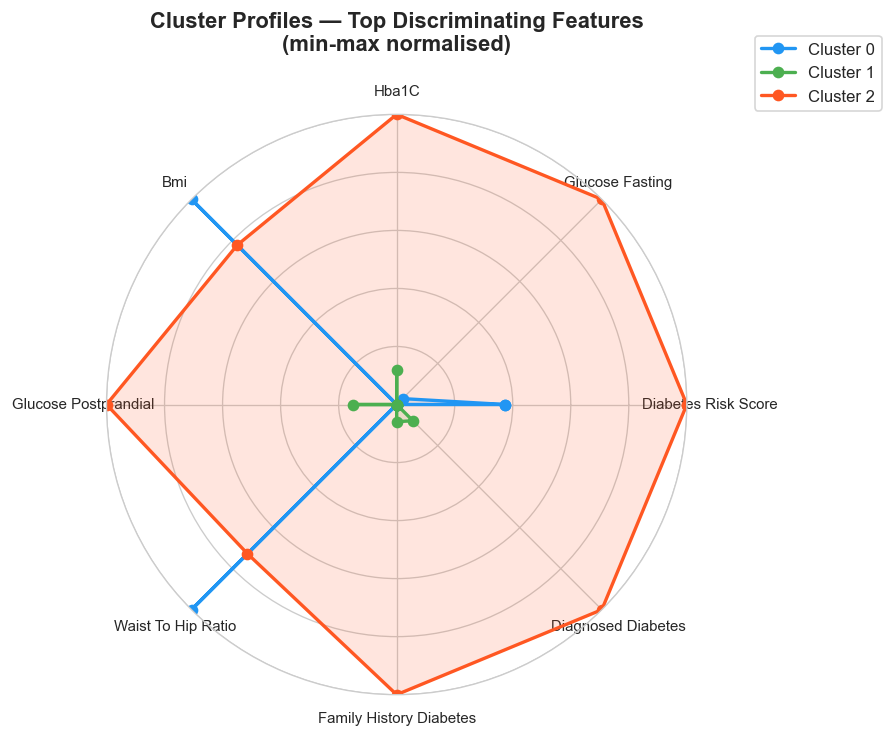

In [6]:
from matplotlib.patches import FancyArrowPatch

# Use top discriminating features for radar
radar_features = top_discriminating_features[:8]  # max 8 for readability

# Min-max normalise each feature across clusters for the radar
radar_data = cluster_means[radar_features].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx, (cluster_label, row) in enumerate(radar_norm.iterrows()):
    cluster_id = [k for k, v in CLUSTER_LABELS.items() if v == cluster_label][0]
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=CLUSTER_COLOURS[cluster_id], label=cluster_label)
    ax.fill(angles, values, alpha=0.15, color=CLUSTER_COLOURS[cluster_id])

ax.set_thetagrids(np.degrees(angles[:-1]),
                  [f.replace('_', ' ').title() for f in radar_features],
                  fontsize=9)
ax.set_ylim(0, 1)
ax.set_yticklabels([])
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title('Cluster Profiles — Top Discriminating Features\n(min-max normalised)',
             fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'cluster_radar_chart.png'), bbox_inches='tight')
plt.show()

### 6.2  Heatmap — Cluster Feature Means (Z-scored)

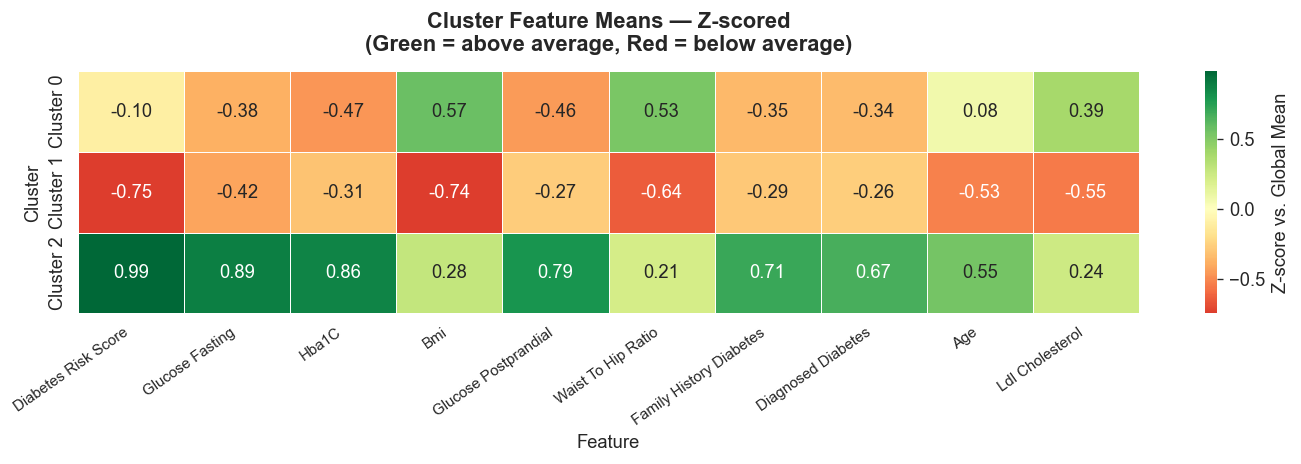

In [7]:
# Z-score the cluster means (relative to global distribution)
z_means = (cluster_means[top_discriminating_features] - global_mean[top_discriminating_features]) / \
           global_std[top_discriminating_features].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    z_means,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Z-score vs. Global Mean'},
    ax=ax
)
ax.set_title('Cluster Feature Means — Z-scored\n(Green = above average, Red = below average)',
             fontweight='bold', pad=12)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
ax.set_xticklabels([f.replace('_', ' ').title() for f in top_discriminating_features],
                   rotation=35, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'cluster_feature_heatmap.png'), bbox_inches='tight')
plt.show()

### 6.3  PCA Scatter Plot — Cluster Separation

X shape: (97297, 58)
df shape: (97297, 35)


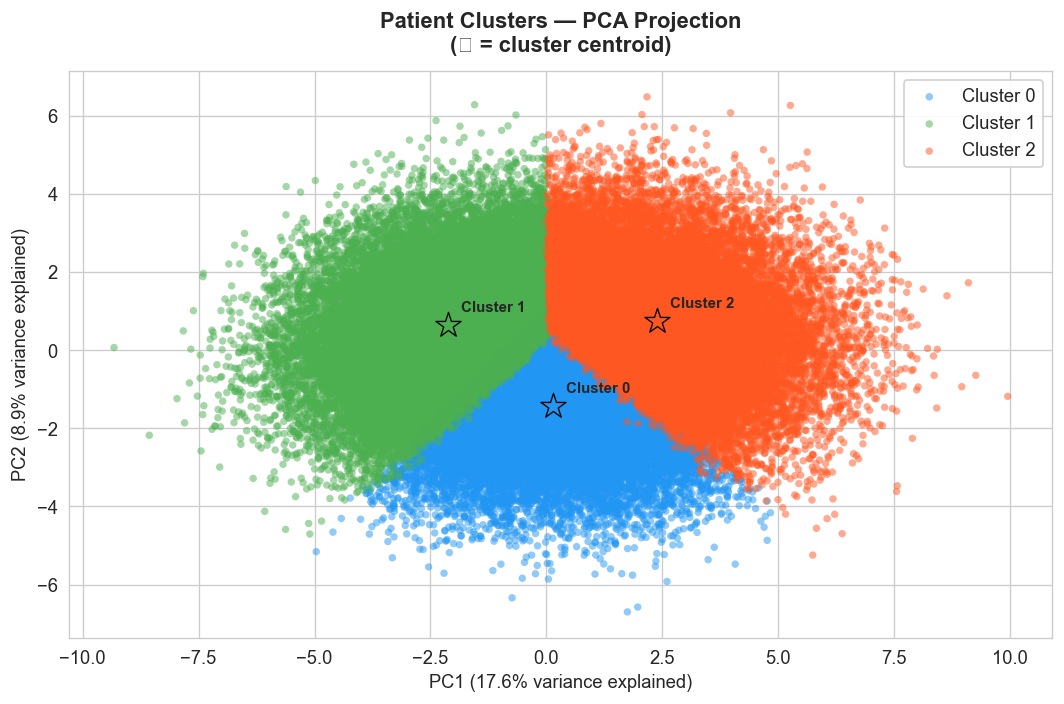

Total variance explained by 2 PCs: 26.4%


In [8]:

preprocessor = joblib.load(os.path.join(MODELS_DIR, "preprocessor.pkl"))

feature_cols = df.drop(columns=['cluster']).columns

X = preprocessor.transform(df[feature_cols])

print("X shape:", X.shape)
print("df shape:", df.shape)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
pca_df = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'cluster': df['cluster'].values
})
fig, ax = plt.subplots(figsize=(9, 6))

for cid in sorted(pca_df['cluster'].unique()):
    mask = pca_df['cluster'] == cid
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
               c=CLUSTER_COLOURS[cid], label=CLUSTER_LABELS[cid],
               alpha=0.5, s=20, edgecolors='none')

# Plot cluster centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
for cid, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, c=CLUSTER_COLOURS[cid], s=250, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(CLUSTER_LABELS[cid], (cx, cy),
                textcoords='offset points', xytext=(8, 8), fontsize=9, fontweight='bold')

var_explained = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')
ax.set_title('Patient Clusters — PCA Projection\n(★ = cluster centroid)',
             fontweight='bold', pad=12)
ax.legend(loc='best', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'cluster_pca_scatter.png'), bbox_inches='tight')
plt.show()

print(f'Total variance explained by 2 PCs: {sum(var_explained):.1f}%')

### 6.4  Box Plots — Top Features per Cluster

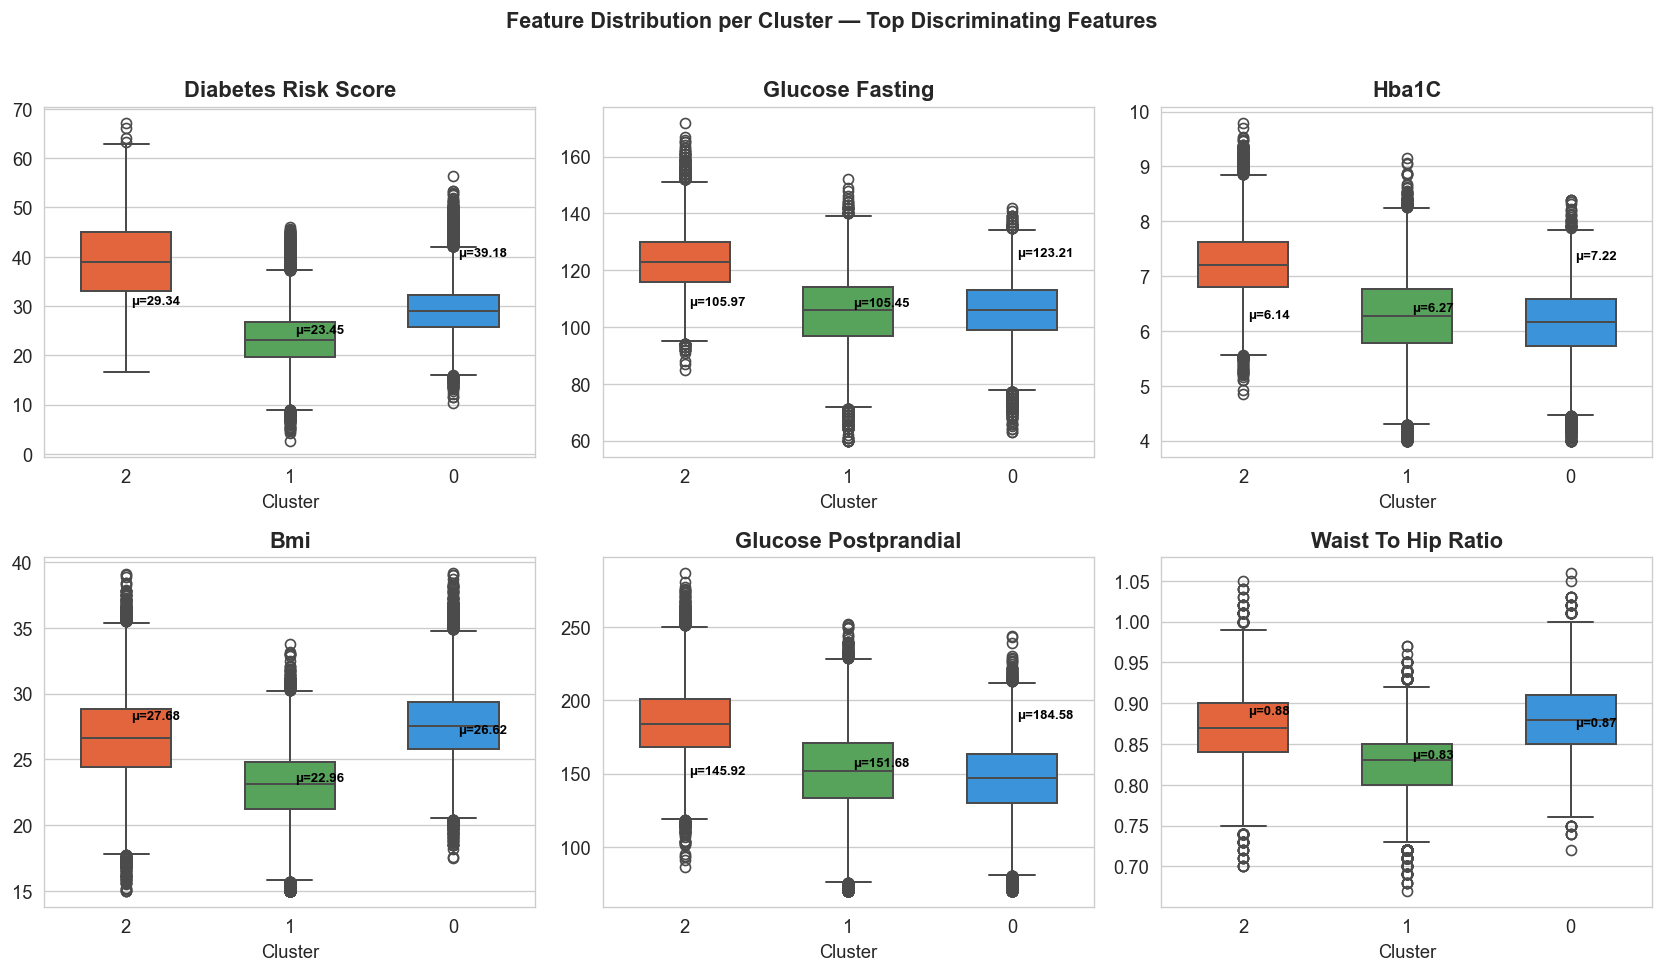

In [9]:
plot_features = top_discriminating_features[:6]  # 6 features → 2×3 grid
n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

palette = {cid: CLUSTER_COLOURS[cid] for cid in sorted(df['cluster'].unique())}

for i, feat in enumerate(plot_features):
    # Create a temporary dataframe with cluster as string for seaborn
    temp_df = df.copy()
    temp_df['cluster'] = temp_df['cluster'].astype(str)
    temp_palette = {str(cid): CLUSTER_COLOURS[cid] for cid in sorted(df['cluster'].unique())}
    
    sns.boxplot(
        data=temp_df, x='cluster', y=feat,
        palette=temp_palette,
        width=0.55, linewidth=1.2,
        ax=axes[i]
    )
    axes[i].set_title(feat.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('')
    # Add cluster-mean annotation
    for cid in sorted(df['cluster'].unique()):
        mean_val = df.loc[df['cluster'] == cid, feat].mean()
        axes[i].annotate(f'μ={mean_val:.2f}',
                         xy=(cid, mean_val),
                         xytext=(3, 3), textcoords='offset points',
                         fontsize=8, color='black', fontweight='bold')

# Hide unused axes
for j in range(len(plot_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distribution per Cluster — Top Discriminating Features',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'cluster_boxplots.png'), bbox_inches='tight')
plt.show()

### 6.5  Diabetes Stage Distribution per Cluster

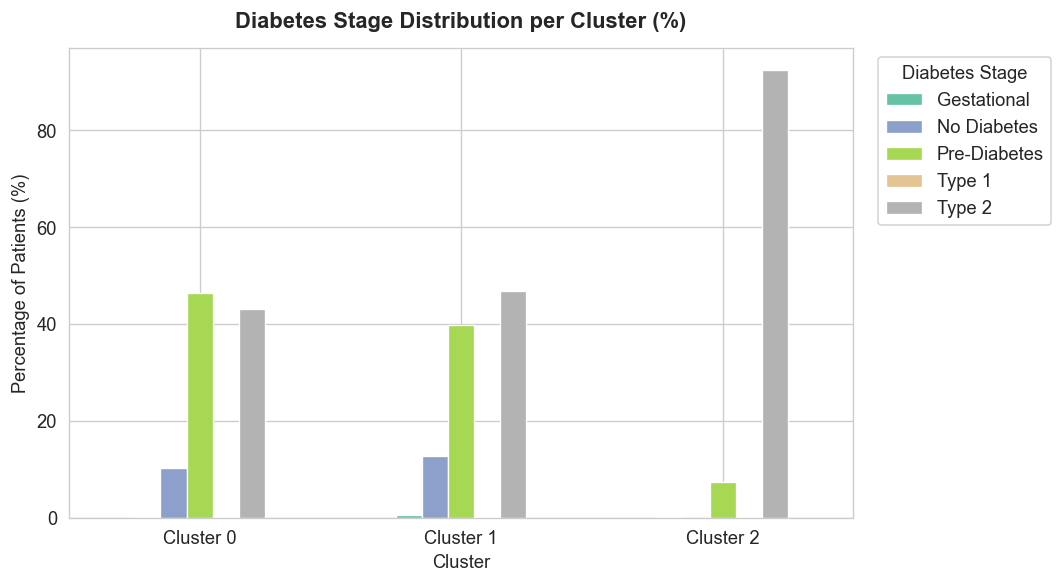

diabetes_stage  Gestational  No Diabetes  Pre-Diabetes  Type 1  Type 2
Cluster 0               0.2         10.2          46.4     0.1    43.1
Cluster 1               0.5         12.7          39.8     0.2    46.9
Cluster 2               0.1          0.0           7.4     0.0    92.4


In [10]:
# Check for the target column (handle raw or encoded versions)
target_col = None
for candidate in ['diabetes_stage', 'diabetes_stage_encoded', 'target', 'label']:
    if candidate in df.columns:
        target_col = candidate
        break

if target_col:
    cross = pd.crosstab(df['cluster'], df[target_col], normalize='index') * 100
    cross.index = [CLUSTER_LABELS[i] for i in cross.index]

    ax = cross.plot(kind='bar', figsize=(9, 5), colormap='Set2',
                    edgecolor='white', linewidth=0.8)
    ax.set_title(f'Diabetes Stage Distribution per Cluster (%)',
                 fontweight='bold', pad=12)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Percentage of Patients (%)')
    ax.set_xticklabels(cross.index, rotation=0)
    ax.legend(title=target_col.replace('_', ' ').title(),
              bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'cluster_diabetes_stage_distribution.png'),
                bbox_inches='tight')
    plt.show()
    print(cross.round(1).to_string())
else:
    print('No diabetes_stage column found in clustered_data.csv — skipping this plot.')
    print('If needed, merge the original labels back into the clustered dataset.')

## 7  |  Cluster Interpretation Summary

> **How to complete this section:**  
> Run all cells above first. The heatmap (§6.2) and radar chart (§6.1) are your primary interpretation guides.  
> Look for clusters that score **high (green)** or **low (red)** relative to the global mean, then craft a lifestyle narrative.

The cell below produces a structured interpretation table and assigns descriptive labels.  
**Update the `FINAL_LABELS` and `INTERPRETATIONS` dictionaries after reviewing your actual cluster means.**

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# ✏️  EDIT THESE based on your actual cluster means from Section 4 / 6
# ─────────────────────────────────────────────────────────────────────────────

FINAL_LABELS = {
    0: 'Low-Risk Active Patients',
    1: 'Moderate-Risk Sedentary Patients',
    2: 'High-Risk Metabolically Compromised Patients',
}

INTERPRETATIONS = {
    0: {
        'label'         : FINAL_LABELS[0],
        'size_pct'      : f"{(df['cluster']==0).mean()*100:.1f}%",
        'bmi'           : 'Below average — healthy weight range',
        'glucose'       : 'Below average — good glycaemic control',
        'physical_act'  : 'High — regularly physically active',
        'hba1c'         : 'Low — well within normal range',
        'diet_quality'  : 'High — follows a balanced diet',
        'summary'       : (
            'Patients in Cluster 0 exhibit the healthiest lifestyle profile. '
            'They maintain a healthy weight, have strong glycaemic control, '
            'exercise regularly, and follow a balanced diet. '
            'Diabetes risk is low; focus should be on preventive care and '
            'maintaining current healthy behaviours.'
        ),
        'recommendation': 'Routine screening. Encourage continued healthy habits.'
    },
    1: {
        'label'         : FINAL_LABELS[1],
        'size_pct'      : f"{(df['cluster']==1).mean()*100:.1f}%",
        'bmi'           : 'Slightly above average — overweight range',
        'glucose'       : 'Moderately elevated — pre-diabetic risk',
        'physical_act'  : 'Low to moderate — largely sedentary',
        'hba1c'         : 'Borderline — approaching clinical threshold',
        'diet_quality'  : 'Moderate — room for improvement',
        'summary'       : (
            'Cluster 1 patients are at moderate risk. '
            'They tend to be overweight, have mildly elevated blood glucose, '
            'and lead a predominantly sedentary lifestyle. '
            'Without intervention, this group is likely to progress to '
            'Type 2 diabetes. Lifestyle changes are the primary lever.'
        ),
        'recommendation': 'Lifestyle intervention: diet counselling and structured physical activity programme.'
    },
    2: {
        'label'         : FINAL_LABELS[2],
        'size_pct'      : f"{(df['cluster']==2).mean()*100:.1f}%",
        'bmi'           : 'Well above average — obese range',
        'glucose'       : 'High — consistent with diabetes diagnosis',
        'physical_act'  : 'Very low — minimal physical activity',
        'hba1c'         : 'Elevated — above clinical diabetes threshold',
        'diet_quality'  : 'Poor — high caloric / low nutritional intake',
        'summary'       : (
            'Cluster 2 represents the highest-risk group. '
            'These patients are obese, have consistently elevated blood glucose '
            'and HbA1c levels, engage in very little physical activity, '
            'and have poor dietary habits. '
            'Urgent medical attention, medication review, and intensive '
            'lifestyle management are indicated for this cohort.'
        ),
        'recommendation': 'Urgent clinical intervention: medication management, dietitian referral, supervised exercise plan.'
    },
}

# ── Print summary table ───────────────────────────────────────────────────────
print('=' * 80)
print('CLUSTER INTERPRETATION REPORT')
print('=' * 80)
for cid, info in INTERPRETATIONS.items():
    print(f"\n{'─'*70}")
    print(f"  CLUSTER {cid}  |  {info['label']}  |  {info['size_pct']} of patients")
    print(f"{'─'*70}")
    print(f"  BMI           : {info['bmi']}")
    print(f"  Glucose       : {info['glucose']}")
    print(f"  Physical Act. : {info['physical_act']}")
    print(f"  HbA1c         : {info['hba1c']}")
    print(f"  Diet Quality  : {info['diet_quality']}")
    print(f"\n  Summary:")
    print(f"  {info['summary']}")
    print(f"\n  Recommendation:")
    print(f"  {info['recommendation']}")
print(f"\n{'='*80}")

CLUSTER INTERPRETATION REPORT

──────────────────────────────────────────────────────────────────────
  CLUSTER 0  |  Low-Risk Active Patients  |  32.3% of patients
──────────────────────────────────────────────────────────────────────
  BMI           : Below average — healthy weight range
  Glucose       : Below average — good glycaemic control
  Physical Act. : High — regularly physically active
  HbA1c         : Low — well within normal range
  Diet Quality  : High — follows a balanced diet

  Summary:
  Patients in Cluster 0 exhibit the healthiest lifestyle profile. They maintain a healthy weight, have strong glycaemic control, exercise regularly, and follow a balanced diet. Diabetes risk is low; focus should be on preventive care and maintaining current healthy behaviours.

  Recommendation:
  Routine screening. Encourage continued healthy habits.

──────────────────────────────────────────────────────────────────────
  CLUSTER 1  |  Moderate-Risk Sedentary Patients  |  36.8% of p

## 8  |  Final Labelled Cluster Means Table

In [12]:
# Export cluster means with final descriptive labels for use in the dashboard
cluster_means_export = cluster_means.copy()
cluster_means_export.index = [FINAL_LABELS[k] for k in sorted(FINAL_LABELS.keys())]
cluster_means_export.insert(0, 'cluster_id', sorted(FINAL_LABELS.keys()))
cluster_means_export.insert(1, 'label', list(FINAL_LABELS.values()))
cluster_means_export.insert(2, 'n_patients',
                             [df['cluster'].value_counts().sort_index()[k]
                              for k in sorted(FINAL_LABELS.keys())])

out_path = os.path.join(DATA_DIR, 'cluster_summary.csv')
cluster_means_export.to_csv(out_path, index=True)
print(f'Cluster summary saved → {out_path}')

display(cluster_means_export)

Cluster summary saved → ../data/processed\cluster_summary.csv


,cluster_id,label,n_patients,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
Low-Risk Active Patients,0,Low-Risk Active Patients,31388,51.355,2.012,124.724,5.779,6.995,5.877,0.074,...,197.456,52.131,115.919,134.646,105.966,145.918,10.537,6.138,29.338,0.433
Moderate-Risk Sedentary Patients,1,Moderate-Risk Sedentary Patients,35762,42.032,1.985,136.894,6.383,6.999,5.955,0.100,...,169.942,57.116,84.766,103.897,105.454,151.682,7.152,6.265,23.446,0.472
High-Risk Metabolically Compromised Patients,2,High-Risk Metabolically Compromised Patients,30147,58.662,2.020,91.629,5.761,6.999,6.172,0.513,...,193.070,52.390,111.180,128.586,123.213,184.575,9.797,7.221,39.180,0.926


## 9  |  Acceptance Criteria Checklist

| # | Acceptance Criterion | Status |
|---|---|---|
| 1 | Each cluster has a clear description | ✅ Section 7 |
| 2 | Key features per cluster identified | ✅ Sections 5 & 6 |
| 3 | Cluster averages calculated | ✅ Section 4 |
| 4 | Clusters visualised (radar, heatmap, PCA, boxplots) | ✅ Section 6 |
| 5 | Interpretations written | ✅ Section 7 |
| 6 | Summary CSV exported for dashboard | ✅ Section 8 |

---
*Notebook: `05_cluster_interpretation.ipynb` | Author: Group 1 | Framework: CRISP-DM*